## Хинчагов Руслан - ЭФБО-08-24 
Математика в программировании - 1 контрольная работа 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from fractions import Fraction
from scipy import linalg

np.set_printoptions(precision=6, suppress=True)

## Задача 1.1 

Ключевое отличие SymPy от NumPy в том, что SymPy сохраняет дроби и свободный параметр, NumPy работает с приближенными числами. 

In [ ]:
# Решение через Sympy

A = sp.Matrix([
    [1, 5, -2, 0],
    [-3, 1, 9, -5], 
    [4, -8, -1, 7]
])

b = sp.Matrix([-7, 9, 0])

augmented = A.row_join(b)
rref_matrix, pivots = augmented.rref()

print(rref_matrix)
print(pivots)

Matrix([[1, 0, 0, 8/7, -11/7], [0, 1, 0, -2/7, -6/7], [0, 0, 1, -1/7, 4/7]])
(0, 1, 2)


In [ ]:
# Решение через NumPy 

A_np = np.array([
    [1, 5, -2, 0],
    [-3, 1, 9, -5],
    [4, -8, -1, 7]
], dtype=float)

b_np = np.array([-7, 9, 0], dtype=float)

t = 0 

A_reduced = A_np[:, :3]
b_reduced = b_np - A_np[:, 3] * t

solution = np.linalg.solve(A_reduced, b_reduced)
print(solution)

[-1.57142857 -0.85714286  0.57142857]


## Задача 1.2 

SymPy дает точный RREF, что удобно для вывода общего решения. 
NumPy дает только численную проверку ранга

In [5]:
A = sp.Matrix([
    [5, -1, 5, 9, -2],
    [3, 0, 6, 9, -1],
    [2, 0, 4, 6, -1]
])

b = sp.Matrix([-3, 4, 0])

rref_matrix, pivots = A.row_join(b).rref()

rref_matrix, pivots

(Matrix([
 [1, 0, 2, 3, 0, 4],
 [0, 1, 5, 6, 0, 7],
 [0, 0, 0, 0, 1, 8]]),
 (0, 1, 4))

In [9]:
A_np = np.array([[5, -1, 5, 9, -2],
                 [3,  0, 6, 9, -1],
                 [2,  0, 4, 6, -1]], dtype=float)
b_np = np.array([-3, 4, 0], dtype=float)

# Проверка ранга
rank_A = np.linalg.matrix_rank(A_np)
rank_Ab = np.linalg.matrix_rank(np.hstack([A_np, b_np.reshape(-1,1)]))
rank_A, rank_Ab

(np.int64(3), np.int64(3))

In [6]:
# Проверка

s, t = sp.symbols('s t')

solution = sp.Matrix([
    4 - 2*s - 3*t,
    7 - 5*s - 6*t,
    s,
    t,
    8
])

A * solution

Matrix([
[-3],
[ 4],
[ 0]])

## Задача 1.3 

SymPy дает символьное решение, в котором сразу видна зависимость. 
NumPy дает численное решение двух линейных систем 

In [7]:
x, y, z, u = sp.symbols('x y z u')

equations = [
    sp.Eq(32*x + 97*y + 90*z + 48*u, 47),
    sp.Eq(35*x + 84*y + 91*z + 54*u, 40),
    sp.Eq(17*x + 18*y + 21*z + 13*u, 37)
]

solution = sp.linsolve(
    [eq.lhs - eq.rhs for eq in equations],
    [x, y, z, u]
)

solution

{(36121/10976 - u/10976, 2131*u/5488 + 6325/5488, -10447*u/10976 - 20745/10976, u)}

In [8]:
u_expr = 36121 - 10976*x

y_expr = sp.simplify(
    (sp.Integer(6325) + 2131*u_expr) / 5488
)

sp.expand(y_expr)

14027 - 4262*x

In [10]:
A_yzu = np.array([[97, 90, 48],
                  [84, 91, 54],
                  [18, 21, 13]], dtype=float)

coef_x = np.array([32, 35, 17], dtype=float)

rhs = np.array([47, 40, 37], dtype=float)

a_vec = np.linalg.solve(A_yzu, rhs)

b_vec = np.linalg.solve(A_yzu, -coef_x)

a_vec[0], b_vec[0]  

(np.float64(14027.000000001464), np.float64(-4262.000000000444))

## Задача 1.4 

NumPy будет быстрее для больших матриц и работает с float 

SymPy дает точные целые числа, что удобно для проверки

In [ ]:
# NumPy 

A = np.array([[3,0,2],[0,1,3],[2,2,0],[0,1,0]])
B = np.array([[1,2,-1,2],[-2,-1,1,2],[2,1,1,2]])
C = np.array([[0,-4,6,1],[2,2,-5,-2],[2,-2,6,4],[1,3,0,1]])

result = A @ B + C
result

array([[ 7,  4,  5, 11],
       [ 6,  4, -1,  6],
       [ 0,  0,  6, 12],
       [-1,  2,  1,  3]])

In [ ]:
# SymPy

A = sp.Matrix([[3,0,2],[0,1,3],[2,2,0],[0,1,0]])
B = sp.Matrix([[1,2,-1,2],[-2,-1,1,2],[2,1,1,2]])
C = sp.Matrix([[0,-4,6,1],[2,2,-5,-2],[2,-2,6,4],[1,3,0,1]])

result = A * B + C
result

Matrix([
[ 7, 4,  5, 11],
[ 6, 4, -1,  6],
[ 0, 0,  6, 12],
[-1, 2,  1,  3]])

## Задача 1.5 

Использовал SymPy т.к. не смог найти альтернативу, он дал точные определите и смог вывести формулу

In [ ]:
# SymPy

def det_min(n):
    A = sp.Matrix(n, n, lambda i, j: min(i+1, j+1))
    return A.det()

def det_max(n):
    A = sp.Matrix(n, n, lambda i, j: max(i+1, j+1))
    return A.det()

def det_abs(n):
    A = sp.Matrix(n, n, lambda i, j: abs(i - j))
    return A.det()

for n in range(1, 6):
    print(n, det_min(n), det_max(n), det_abs(n))

1 1 1 0
2 1 -2 -1
3 1 3 4
4 1 -4 -12
5 1 5 32


## Задача 1.6

Использовался случайный поиск 

In [30]:
import itertools, random

def det_random_search(n=6, trials=200000):
    best = 0
    best_M = None
    for _ in range(trials):
        M = np.random.choice([-1,0,1], size=(n,n))
        d = round(np.linalg.det(M))
        if abs(d) > abs(best):
            best = d
            best_M = M.copy()
    return best, best_M

best, M = det_random_search(6, 50000)
best

84

## Задача 1.7 

Т.к. матрица почти диагональна использовалась формула для определителя и следа обратной 

In [33]:
n = 80000
d = np.linspace(0.99, 1.01, n)

det = np.prod(d) - 0.57*0.03*np.prod(d[2:])
det

np.float64(0.2589791138652249)

## Задача 1.8 

NumPy использован для формирования диагонали

In [ ]:

n = 43000

q = 1.07 ** (1 / (n - 1))        
d = q ** np.arange(n)               

d_inv = 1.0 / d                     


step = (1.10 - 1.0) / (n - 1)
a12 = 1.0 + step                   

denom = 1.0                         

B_diag = d_inv
B_01 = -a12 * d_inv[0] * d_inv[1]

print(f"B[0,1] = {B_01:.6f}")
print(f"min(B) = {min(B_01, d_inv.min()):.6f}")
print(f"sum(B) = {B_diag.sum() + B_01:.4f}")

B[0,1] = -1.000001
min(B) = -1.000001
sum(B) = 41576.5987


## Задача 1.9

NumPy быстр для больших диапазонов

SymPy дает точные рациональные вычисления 

In [40]:
gamma = 0.057
A = np.array([[7*gamma, 14*gamma],
              [9*gamma, 1*gamma]])
I = np.eye(2)

def S(m, n):
    total = np.zeros((2,2))
    P = np.linalg.matrix_power(A, m)
    for i in range(m, n+1):
        total += P
        P = P @ A
    return total

S_4_70 = S(4, 70)
S_4_70.max()

np.float64(3.609679030803461)

In [ ]:
from sympy import N

g = sp.Rational(57, 1000)
A = sp.Matrix([[7*g, 14*g],[9*g, 1*g]])
I = sp.eye(2)

def S_sym(m, n):
    return sum((A**i for i in range(m, n+1)), sp.zeros(2, 2))

S_sym(4, 70).applyfunc(lambda x: N(x, 10))

Matrix([
[3.609679031, 3.433099565],
[2.206992578, 2.138350646]])

## Задача 1.10 

Благодаря SymPy удается получить точный полином. 

In [ ]:
x = sp.symbols('x')
M = sp.Matrix([
    [7, 5, 5, x],
    [2, 2, 6, 9],
    [3, x, 8, 0],
    [3, 1, 1, 0]
])
det_M = sp.expand(M.det())
det_M

poly = sp.Poly(det_M, x)
poly.all_coeffs()  

[16, -116, 576]

## Задача 1.11

NumPy + math.comb быстро, но можно оптимизировать через треугольник Паскаля по mod 2

SymPy медленнее

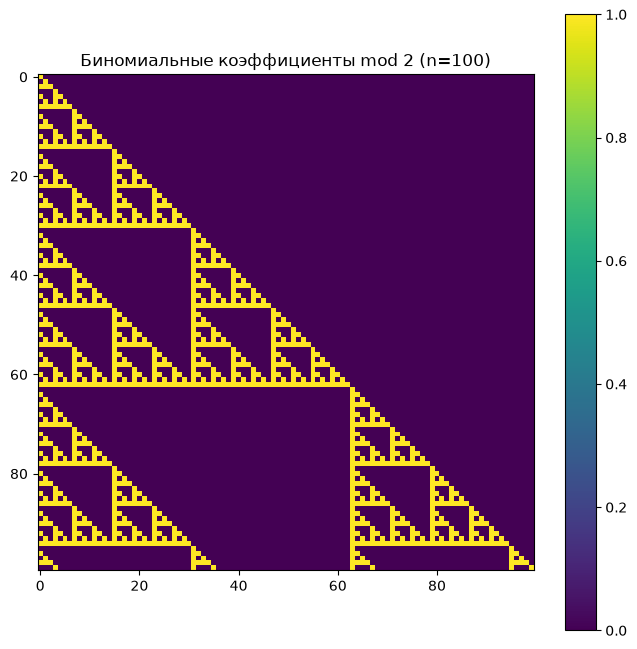

In [43]:
import matplotlib.pyplot as plt
from math import comb

n = 100
M = np.zeros((n, n), dtype=int)
for i in range(1, n+1):
    for j in range(1, i+1):
        M[i-1, j-1] = comb(i, j) % 2

plt.figure(figsize=(8,8))
plt.imshow(M, cmap='viridis', interpolation='none')
plt.title('Биномиальные коэффициенты mod 2 (n=100)')
plt.colorbar()
plt.show()

In [45]:
from sympy import binomial

M = sp.Matrix(n, n, lambda i, j: binomial(i+1, j+1) % 2 if j <= i else 0)
M

Matrix([
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Задача 1.12 

scipy.linalg.hadamard предаставляет готовую матрицу Адамара 

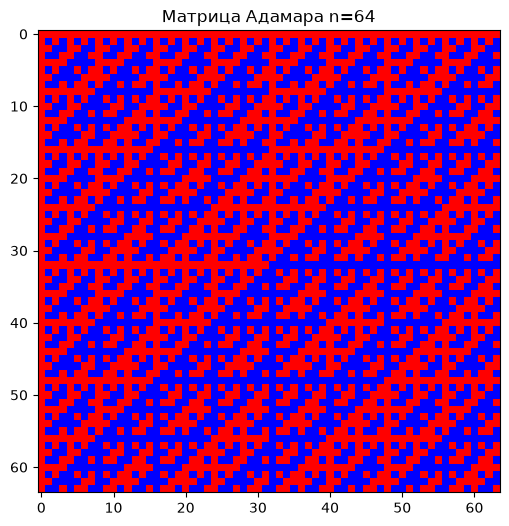

In [47]:
from scipy.linalg import hadamard

H1 = np.array([[1]])
H2 = hadamard(2)
H4 = hadamard(4)

def H_k(k):
    return hadamard(2**k)

plt.figure(figsize=(6,6))
plt.imshow(H_k(6), cmap='bwr', interpolation='none')
plt.title('Матрица Адамара n=64')
plt.show()

## Задача 1.13 

NymPy дает численные комплексные собственные значения 

SymPy точные, которые можно найти аналитически

In [48]:
A = np.array([[14,10,21],[12,15,26],[18,11,27]])
eigvals, eigvecs = np.linalg.eig(A)
eigvals, eigvecs

(array([52.062319+0.j      ,  1.96884 +0.344789j,  1.96884 -0.344789j]),
 array([[ 0.50156 +0.j      ,  0.197542-0.070147j,  0.197542+0.070147j],
        [ 0.599771+0.j      ,  0.833705+0.j      ,  0.833705-0.j      ],
        [ 0.623468+0.j      , -0.509025+0.043431j, -0.509025-0.043431j]]))

In [49]:
A = sp.Matrix([[14,10,21],[12,15,26],[18,11,27]])
A.eigenvals()
A.eigenvects()

[(56/3 + (-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3) + 2509/(9*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3)),
  1,
  [Matrix([
   [9973/1986 + 107*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3)/331 - 11*(56/3 + (-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3) + 2509/(9*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3)))**2/1986 + 268463/(2979*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3))],
   [  -8912/993 - 363805/(2979*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3)) + 3*(56/3 + (-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3) + 2509/(9*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3)))**2/331 - 145*(-1/2 - sqrt(3)*I/2)*(sqrt(249547)/3 + 125756/27)**(1/3)/331],
   [                                                                                                                                                                                                                                              

## Задача 1.14
 
SymPy позволяет вычислить точный минимальный многочлен 

In [52]:


def minpoly_matrix(M, x=None):
    """Вычисляет минимальный многочлен матрицы M."""
    if x is None:
        x = sp.Symbol('x')
    
    n = M.shape[0]
    I = sp.eye(n)
    
    v = sp.Matrix([sp.randprime(1, 100) for _ in range(n)])
    
    
    vectors = [v]
    Mv = v
    for _ in range(n):
        Mv = M * Mv
        vectors.append(Mv)
    
    N = sp.Matrix.hstack(*vectors)
    N_rref, pivots = N.rref()
    
    
    k = len(pivots)
    if k == n + 1:  
        return M.charpoly(x).as_expr()  
    
    coeffs = list(N_rref[:k, -1])[::-1]
    return sp.Poly([1] + [-c for c in coeffs], x)


A = sp.Matrix([
    [-3, 7, -6, -1, 8, -3, -2],
    [1, -5, 8, -3, -5, 4, -5],
    [1, 3, -4, 6, -2, 0, 8],
    [-1, 11, -12, 9, 3, -3, 9],
    [-3, 11, -12, 5, 8, -4, 6],
    [-3, 2, 1, -4, 4, 1, -7],
    [1, -5, 6, -2, -4, 3, -2]
])

x = sp.Symbol('x')
mp = minpoly_matrix(A, x)
print("Минимальный многочлен:")
sp.pprint(mp)

Минимальный многочлен:
Poly(x**5 - 4*x**4 + 3*x**3, x, domain='ZZ')


## Задача 1.15 

np.linalg.eigh подойдет для симметричных/эрмитовых матриц, сразу ортонормированный базис

SymPyf даст точные собственные векторы, но нужно ортонормировать вручную

In [53]:
A = np.array([[17,-8,4],[-8,17,-4],[4,-4,11]], dtype=float)
eigvals, eigvecs = np.linalg.eigh(A) 
eigvals, eigvecs

(array([ 9.,  9., 27.]),
 array([[ 0.675314, -0.315446, -0.666667],
        [ 0.729519,  0.152832,  0.666667],
        [ 0.108409,  0.936556, -0.333333]]))

In [55]:
A = sp.Matrix([[17,-8,4],[-8,17,-4],[4,-4,11]])
A.diagonalize(), A.is_symmetric()

((Matrix([
  [1, -1,  2],
  [1,  0, -2],
  [0,  2,  1]]),
  Matrix([
  [9, 0,  0],
  [0, 9,  0],
  [0, 0, 27]])),
 True)

## Задача 1.16 

В NumPy есть удобный инструмент для симметричных матриц - eigh 

In [56]:
A = np.array([
    [3, 4, 0, 0],
    [4, -3, 0, 0],
    [0, 0, 4, -2],
    [0, 0, -2, 1]
], dtype=float)

eigvals, eigvecs = np.linalg.eigh(A)
eigvals, eigvecs

(array([-5.,  0.,  5.,  5.]),
 array([[ 0.447214, -0.      ,  0.      , -0.894427],
        [-0.894427, -0.      ,  0.      , -0.447214],
        [ 0.      , -0.447214, -0.894427, -0.      ],
        [ 0.      , -0.894427,  0.447214, -0.      ]]))

## Задача 1.17 

SymPy потому что нужно символьное приведение квадратичной формы (поворот + сдвиг), и тип кривой определяется через инварианты 

In [60]:
import math 

a11, a12, a22 = 5, 2, 8
a13, a23, a33 = -16, -28, 80

I1 = a11 + a22
I2 = a11*a22 - a12**2
I3 = sp.Matrix([
    [a11, a12, a13],
    [a12, a22, a23],
    [a13, a23, a33]
]).det()

print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"I3 = {I3}")

# Собственные значения квадратичной части
Q = sp.Matrix([[a11, a12], [a12, a22]])
eigvals = Q.eigenvals()
eigvals = sorted(eigvals.keys(), key=lambda x: float(x))
lam1, lam2 = eigvals
print(f"лямбда 1 = {lam1}, лямбда 2 = {lam2}")

# Полуоси
a2 = -I3 / (I1 * lam1)
b2 = -I3 / (I1 * lam2)
print(f"a^2 = {sp.simplify(a2)}")
print(f"b^2 = {sp.simplify(b2)}")


x0, y0 = sp.symbols('x0 y0')
sol = sp.solve([
    a11*x0 + a12*y0 + a13,
    a12*x0 + a22*y0 + a23
], [x0, y0])
print(sol)

tan2phi = 2*a12 / (a11 - a22)
phi = 0.5 * math.atan(tan2phi)
print(f"tan(2φ) = {tan2phi}")
print(f"φ = {phi} рад = {math.degrees(phi):.4f}°")

# Матрица перехода к каноническому базису (собственные векторы)
eigvecs = Q.eigenvects()
for val, mult, vecs in eigvecs:
    v = sp.simplify(vecs[0] / vecs[0].norm())
    print(f"лямбда = {val}, единичный собственный вектор: {v.T}")

I1 = 13
I2 = 36
I3 = -1296
лямбда 1 = 4, лямбда 2 = 9
a^2 = 324/13
b^2 = 144/13
{x0: 2, y0: 3}
tan(2φ) = -1.3333333333333333
φ = -0.4636476090008061 рад = -26.5651°
лямбда = 4, единичный собственный вектор: Matrix([[-2*sqrt(5)/5, sqrt(5)/5]])
лямбда = 9, единичный собственный вектор: Matrix([[sqrt(5)/5, 2*sqrt(5)/5]])


## Задача 1.18

Был выбран SymPy потому что нужно решить систему неравенст. NumPy не работает с символьными неравенствами. 

In [61]:
lam = sp.symbols('lambda', real=True)
Q = sp.Matrix([
    [1, lam, 5],
    [lam, 4, 3],
    [5, 3, 1]
])
D1 = Q[0,0]
D2 = Q[:2,:2].det()
D3 = Q.det()
print("D1 =", D1)
print("D2 =", sp.expand(D2))
print("D3 =", sp.expand(D3))

sol = sp.solve([D1>0, D2>0, D3>0], lam)
print(sol)

D1 = 1
D2 = 4 - lambda**2
D3 = -lambda**2 + 30*lambda - 105
False


## Задача 1.19 

Тоже самое что и у 1.18  


In [62]:
lam = sp.symbols('lambda', real=True)
Q = sp.Matrix([
    [lam, 1, -1],
    [1, -2, 1],
    [-1, 1, -3]
])


negQ = -Q
D1 = negQ[0,0]
D2 = negQ[:2,:2].det()
D3 = negQ.det()
print("D1 =", D1, "D2 =", sp.expand(D2), "D3 =", sp.expand(D3))

sol = sp.solve([D1>0, D2>0, D3>0], lam)
print("Ответ:", sol)

D1 = -lambda D2 = -2*lambda - 1 D3 = -5*lambda - 3
Ответ: lambda < -3/5


## Задача 1.20 

np.linalg.eigvalsh: Достаточно найти знаки собственных значений, точные не нужны 

SymPy если нужны точныен кратности 

In [63]:
A1 = np.array([[2, 4, -2],
               [4, 9, -5],
               [-2, -5, 3]], dtype=float)
A2 = np.array([[2, -2, -2],
               [-2, 3, 4],
               [-2, 4, 6]], dtype=float)

eig1 = np.linalg.eigvalsh(A1)
eig2 = np.linalg.eigvalsh(A2)

def signature(eigs):
    return (sum(e > 1e-10 for e in eigs),
            sum(e < -1e-10 for e in eigs),
            sum(abs(e) <= 1e-10 for e in eigs))

print("eig A1:", eig1, " сигнатура:", signature(eig1))
print("eig A2:", eig2, " сигнатура:", signature(eig2))

eig A1: [-0.        0.442561 13.557439]  сигнатура: (np.int64(2), np.int64(0), np.int64(1))
eig A2: [-0.        1.227998  9.772002]  сигнатура: (np.int64(2), np.int64(0), np.int64(1))
